In [1]:
def compute_aut0_broker_loss(records, metric_map=None):
    if metric_map is None:
        metric_map = AUT0_METRIC_MAP
    """Compute broker-side loss rate from last Prometheus counter value per experiment.

    broker_loss_rate = 1 - (last_outgoing / last_incoming)

    This is independent of the subscriber-log loss rate and can cross-validate it.
    A discrepancy between the two indicates either client-side drops (network/subscriber)
    or measurement error.
    """
    rows = []
    for rec in records:
        broker = rec.get('broker', '?')
        m_in  = metric_map.get(broker, {}).get('incoming')
        m_out = metric_map.get(broker, {}).get('outgoing')
        metrics = rec.get('metrics', {})

        def _last_value(metric_name):
            if not metric_name or metric_name not in metrics or metrics[metric_name] is None:
                return None
            result_list = metrics[metric_name].get('result', [])
            vals = []
            for entry in result_list:
                if entry.get('values'):
                    vals.append(float(entry['values'][-1][1]))
            return sum(vals) if vals else None

        last_in  = _last_value(m_in)
        last_out = _last_value(m_out)

        if last_in and last_in > 0:
            loss_rate = 1.0 - (last_out or 0) / last_in
        else:
            loss_rate = None

        rows.append({
            'broker':       broker,
            'payload_size': rec.get('payload_size', '?'),
            'qos':          rec.get('qos', '?'),
            'incoming':     last_in,
            'outgoing':     last_out,
            'broker_loss_rate': round(loss_rate, 4) if loss_rate is not None else None,
        })

    if rows:
        df_loss = pd.DataFrame(rows).sort_values(['payload_size', 'broker'])
        print(df_loss.to_string(index=False))
        return df_loss
    else:
        print('[skip] No data.')
        return pd.DataFrame()


In [2]:
def _range_to_series(range_data_entry):
    """Convert a single Prometheus range result entry to (timestamps, values) arrays."""
    ts, vals = [], []
    for t, v in range_data_entry.get('values', []):
        ts.append(np.datetime64(int(float(t) * 1e9), 'ns'))
        vals.append(float(v))
    return np.array(ts, dtype='datetime64[ns]'), np.array(vals)


def plot_aut0_range(records, metric_map=None):
    if metric_map is None:
        metric_map = AUT0_METRIC_MAP
    """Plot incoming vs outgoing message counts over time for each AUT0 experiment."""
    if not records:
        print('[skip] No AUT0 Prometheus range JSON files found.')
        return

    # Group by payload_size for one figure per size
    sizes = sorted({r['payload_size'] for r in records})
    brokers_order = ['hivemq', 'emqx', 'mosquitto', 'nanomq', 'rabbitmq']

    for size in sizes:
        size_recs = [r for r in records if r['payload_size'] == size]
        # one subplot per broker
        broker_recs = {r['broker']: r for r in size_recs}
        present = [b for b in brokers_order if b in broker_recs]
        if not present:
            continue

        fig, axes = plt.subplots(1, len(present), figsize=(5 * len(present), 4),
                                 sharey=False)
        if len(present) == 1:
            axes = [axes]
        fig.suptitle(f'AUT0 Broker Message Counts — {size} / qos{size_recs[0]["qos"]}',
                     fontsize=12)

        for ax, broker in zip(axes, present):
            rec = broker_recs[broker]
            metrics = rec.get('metrics', {})
            m_in  = metric_map.get(broker, {}).get('incoming')
            m_out = metric_map.get(broker, {}).get('outgoing')

            for metric_name, label, ls, color in [
                (m_in,  'incoming', '-',  'steelblue'),
                (m_out, 'outgoing', '--', 'darkorange'),
            ]:
                if not metric_name or metric_name not in metrics or metrics[metric_name] is None:
                    continue
                result_list = metrics[metric_name].get('result', [])
                for entry in result_list:
                    ts, vals = _range_to_series(entry)
                    if len(ts):
                        ax.plot(ts, vals, linestyle=ls, color=color, linewidth=2, label=label)

            ax.set_title(broker)
            ax.set_xlabel('Time')
            ax.set_ylabel('Message count (cumulative)')
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
            ax.xaxis.set_major_locator(mdates.AutoDateLocator())
            ax.legend(loc='best', fontsize=8)
            ax.grid(True)

        fig.autofmt_xdate()
        plt.tight_layout()
        plt.savefig(f'aut0_broker_msg_counts_{size}.png', format='png')
        plt.show()


  Loaded emqx_125kb_qos0_20260514T114804_prometheus.json  [emqx / 125kb / qos0]
  Loaded emqx_125kb_qos0_20260514T151703_prometheus.json  [emqx / 125kb / qos0]
  Loaded emqx_16mb_qos0_20260514T164503_prometheus.json  [emqx / 16mb / qos0]
  Loaded emqx_1kb_qos0_20260514T143147_prometheus.json  [emqx / 1kb / qos0]
  Loaded emqx_1mb_qos0_20260514T162037_prometheus.json  [emqx / 1mb / qos0]
  Loaded emqx_35kb_qos0_20260514T145422_prometheus.json  [emqx / 35kb / qos0]
  Loaded hivemq_125kb_qos0_20260514T124102_prometheus.json  [hivemq / 125kb / qos0]
  Loaded hivemq_125kb_qos0_20260514T130625_prometheus.json  [hivemq / 125kb / qos0]
  Loaded hivemq_125kb_qos0_20260514T141621_prometheus.json  [hivemq / 125kb / qos0]
  Loaded hivemq_125kb_qos0_20260514T151225_prometheus.json  [hivemq / 125kb / qos0]
  Loaded hivemq_16mb_qos0_20260514T163851_prometheus.json  [hivemq / 16mb / qos0]
  Loaded hivemq_1kb_qos0_20260514T140326_prometheus.json  [hivemq / 1kb / qos0]
  Loaded hivemq_1kb_qos0_20260514T

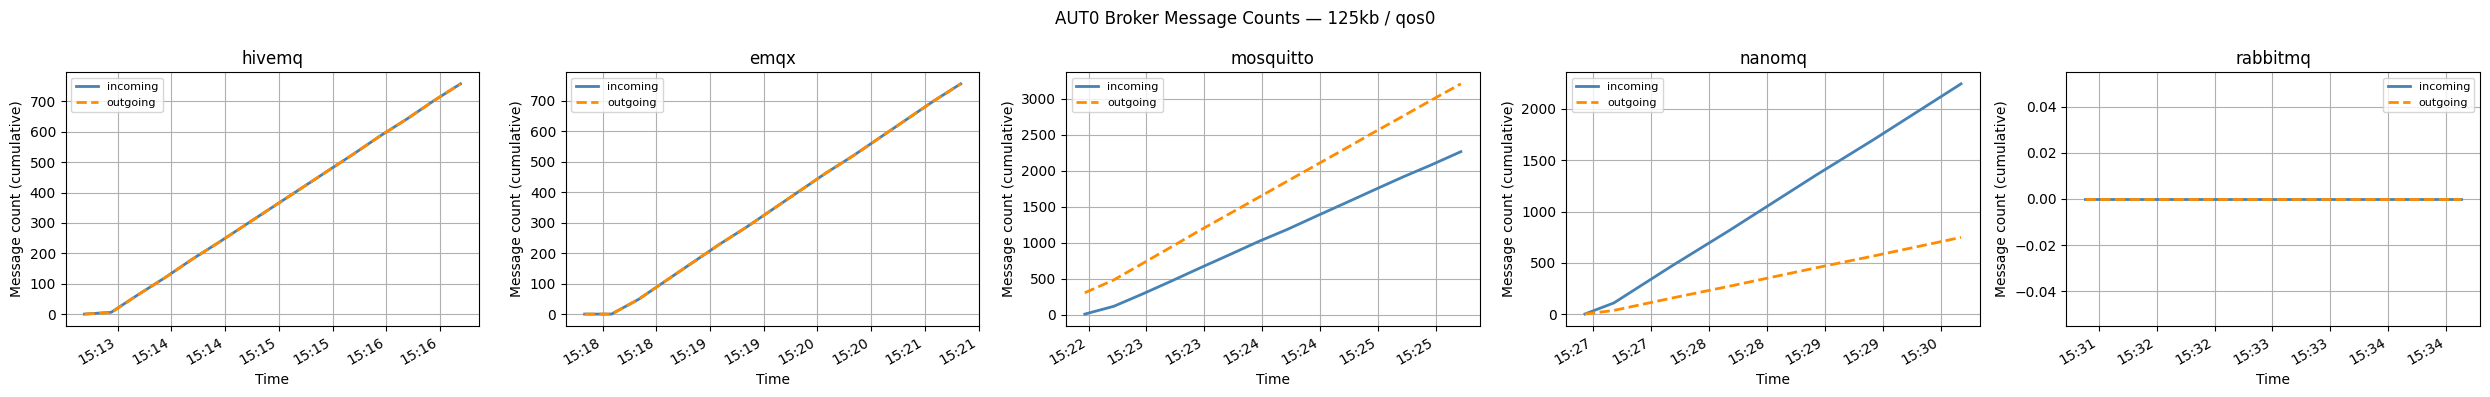

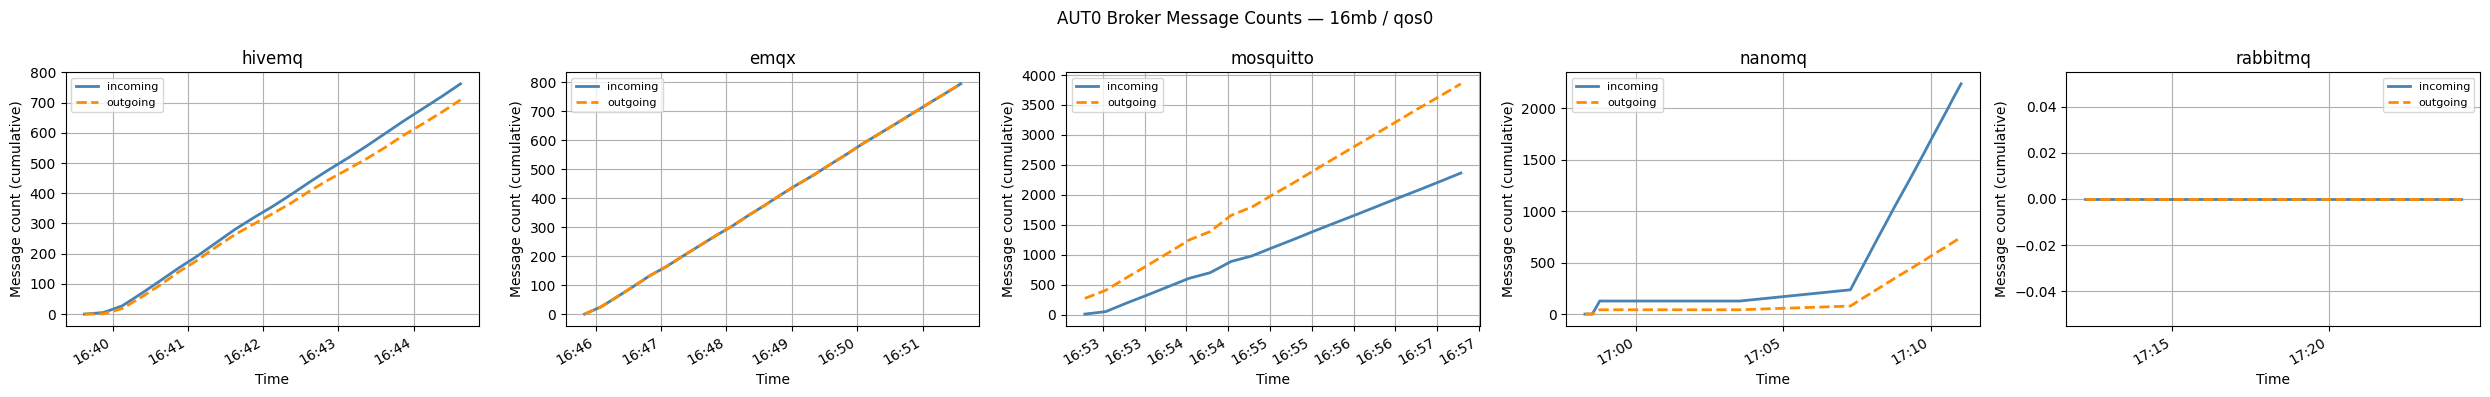

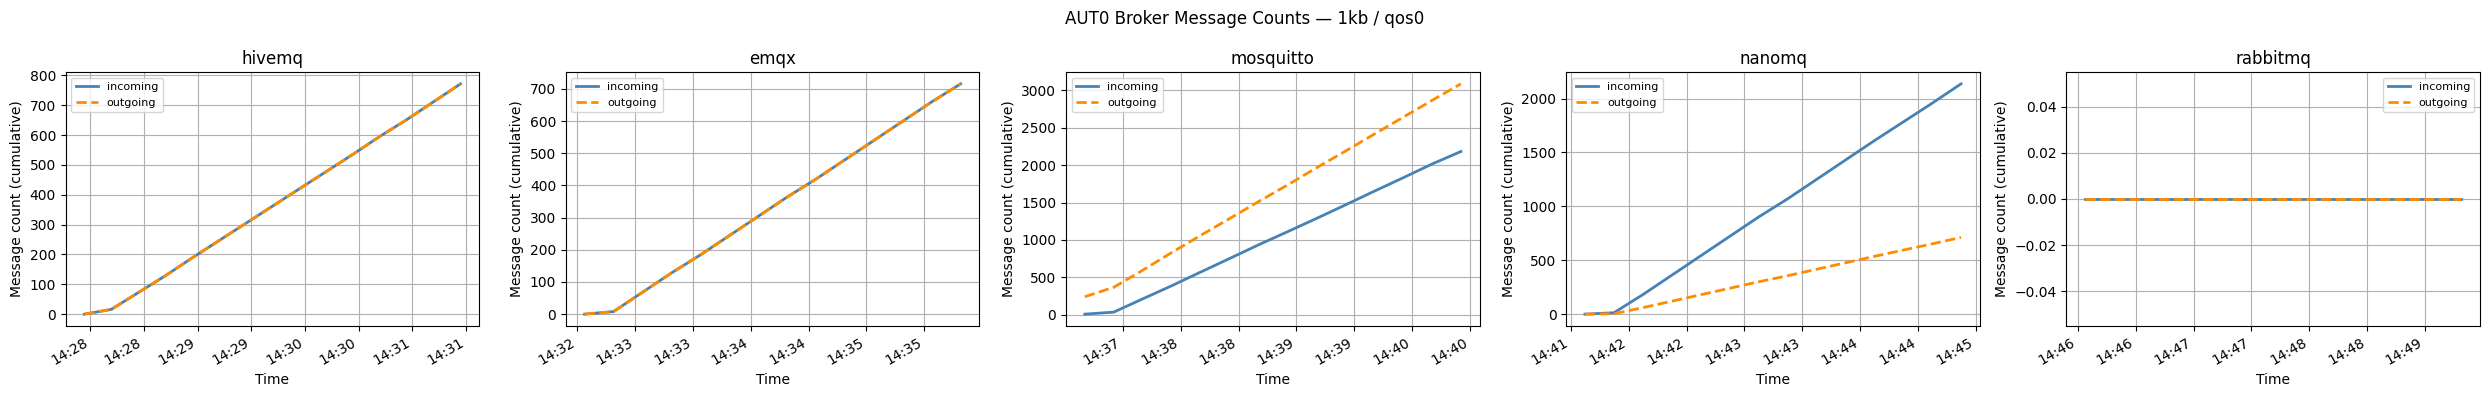

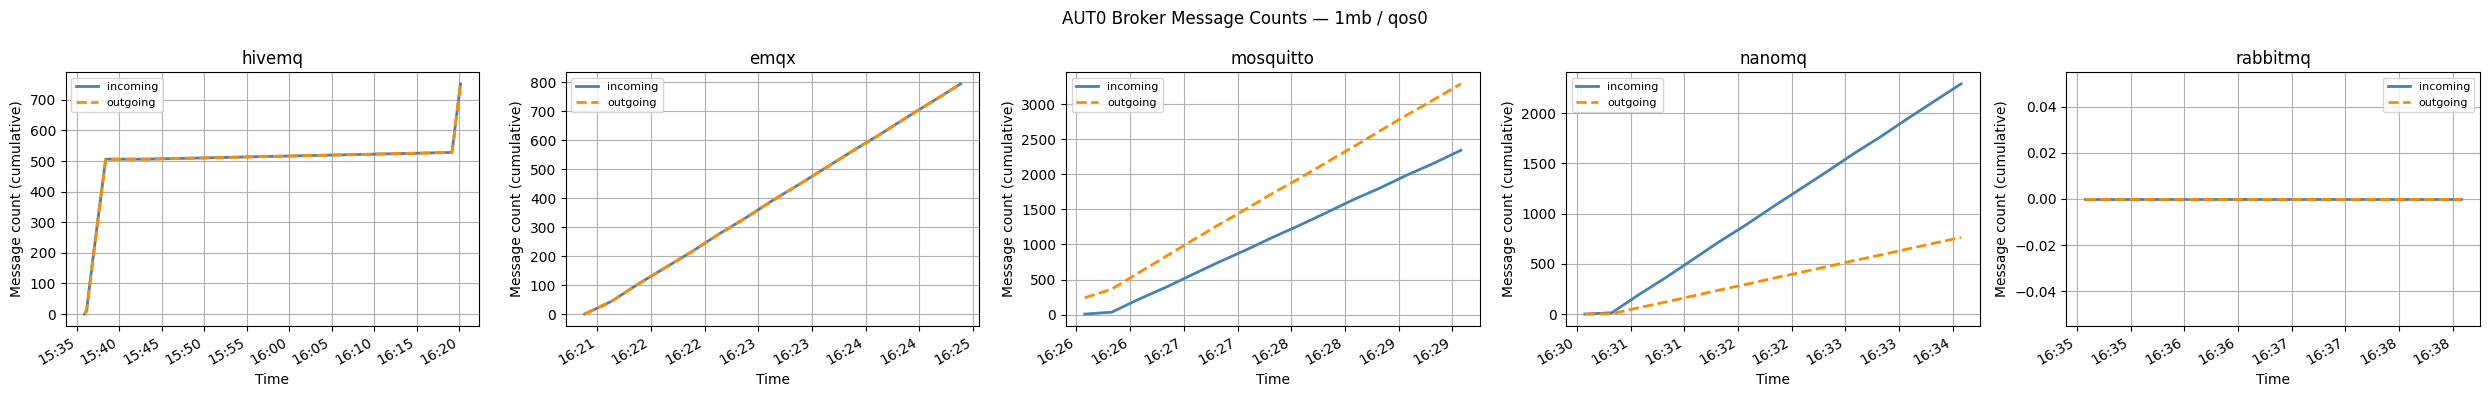

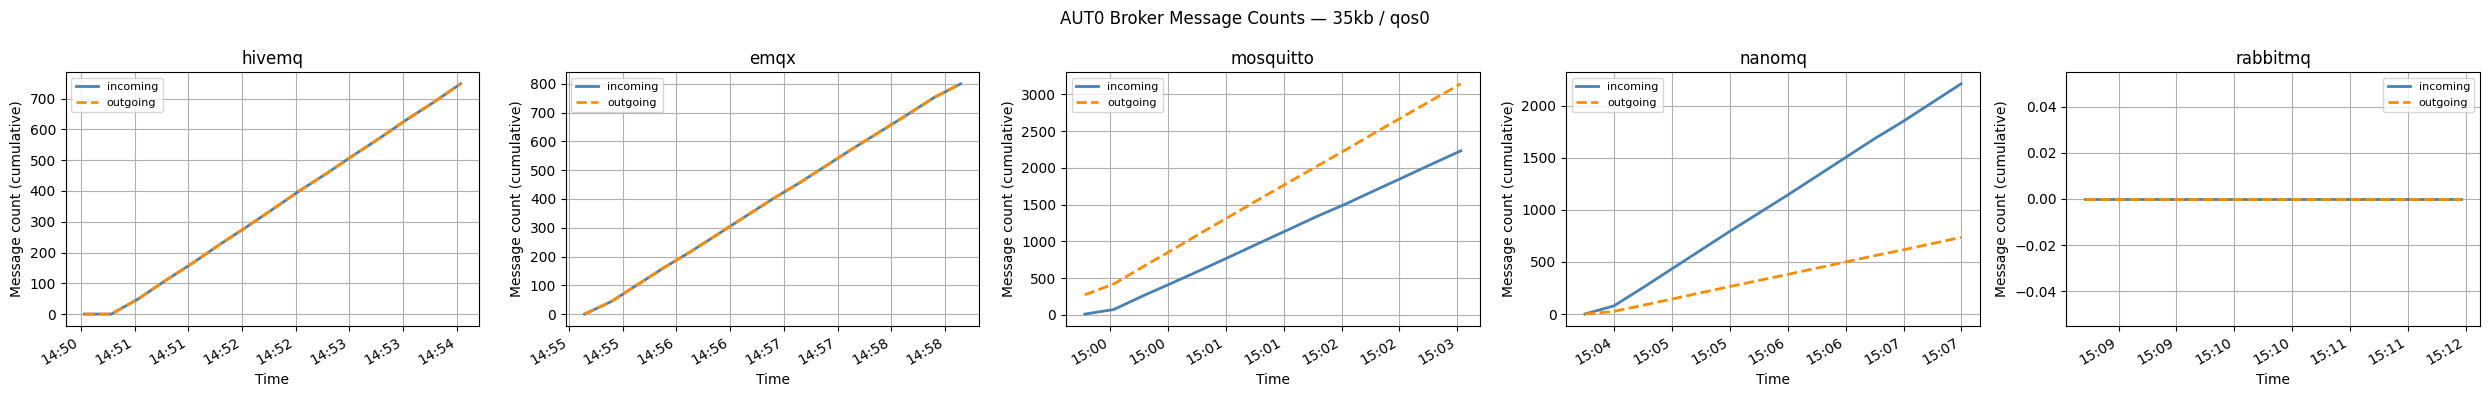

In [3]:
import glob, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Broker metric names for the range-query JSON files ───────────────────────
# Keys 'incoming' and 'outgoing' map to the counter names exposed by each broker's
# Prometheus endpoint (as configured in run_load_updated.py BROKER_CONFIG).
AUT0_METRIC_MAP = {
    'hivemq':    {'incoming': 'com_hivemq_messages_incoming_publish_count',
                  'outgoing': 'com_hivemq_messages_outgoing_publish_count'},
    'emqx':      {'incoming': 'emqx_messages_received',
                  'outgoing': 'emqx_messages_sent'},
    'mosquitto': {'incoming': 'broker_messages_received',
                  'outgoing': 'broker_messages_sent'},
    'nanomq':    {'incoming': 'nanomq_messages_received',
                  'outgoing': 'nanomq_messages_sent'},
    'rabbitmq':  {'incoming': 'rabbitmq_channel_messages_published_total',
                  'outgoing': 'rabbitmq_channel_messages_delivered_total'},
}

AUT0_RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'results'))


def _load_aut0_prometheus_jsons(results_dir):
    """Scan results/<broker>/<size>/qos<N>/*_prometheus.json and load all found files.

    Returns a list of dicts with keys: broker, payload_size, qos, experiment_id,
    start, end, metrics (the raw Prometheus range data keyed by metric name).
    """
    records = []
    pattern = os.path.join(results_dir, '*', '*', '*', '*_prometheus.json')
    for path in sorted(glob.glob(pattern)):
        with open(path) as f:
            data = json.load(f)
        records.append(data)
        print(f"  Loaded {os.path.basename(path)}"
              f"  [{data.get('broker','?')} / {data.get('payload_size','?')} / qos{data.get('qos','?')}]")
    return records


aut0_prom_records = _load_aut0_prometheus_jsons(AUT0_RESULTS_DIR)
print(f"\nTotal experiments: {len(aut0_prom_records)}")

aut0_loss_df = compute_aut0_broker_loss(aut0_prom_records)

plot_aut0_range(aut0_prom_records)

# Prometheus Data Analysis
This notebook loads, processes, and explores data recorded by the benchmarked IoT platform prototype monitoring subsystem. During the benchmark execution, OpenTelemetry agents and the HiveMQ Prometheus extension were used to collect measurements. These recorded measurements were stored in the Prometheus time-series database, which records are part of the logs provided in the replication package. Instructions on extracting the recorded measurements and running them in a new instance of Prometheus can be found in the README in the root directory of this repository.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from matplotlib import colormaps
import matplotlib.dates as mdates
import pandas as pd

## JSON data file paths

In [5]:
cwd = os.getcwd()
transformer_logs= f'{cwd}/../transformer/logs/'
incomming_file='brokers_incomming_msgs.json'
outgoing_file='brokers_outgoing_msgs.json'

## Benchmark Parameters

Benchmark parameters used in the setup for execution of the system under test.

In [6]:
auts=['aut1_15b','aut1_29b','aut2']
qoss =['qos0', 'qos1', 'qos2']
gateways=['provider1.gateway1','provider1.gateway2','provider2.gateway1']
gateways_payloads=['125KB','35KB','1.5KB']
# Brokers Services
source_brokers=['ingestion-service1','ingestion-service2']
destination_brokers=['core-service']

## JSON Parser

In [7]:
def parse_json_to_list(json_obj, aut, qos):
    if json_obj['status'] != 'success':
        raise ValueError("Data retrieval was not successful")
    
    results = json_obj['data']['result']
    
    data_list = []
    for entry in results:
        metric_name = entry['metric']['__name__']
        instance = entry['metric'].get('instance', 'N/A')
        job = entry['metric'].get('job', 'N/A')
        exported_instance = entry['metric'].get('exported_instance', 'N/A')
        exported_job = entry['metric'].get('exported_job', 'N/A')
        
        values = entry['values']
        
        for value in values:
            timestamp, count = value
            # Convert timestamp from seconds to nanoseconds
            nanosecond_timestamp = int(float(timestamp) * 1e9)
            data_list.append((
                np.datetime64(nanosecond_timestamp,'ns'), 
                float(count), 
                metric_name, 
                instance, 
                job, 
                exported_instance, 
                exported_job, 
                aut, 
                qos
            ))
    
    return data_list

In [8]:
def get_last_data_points_for_jobs(numpy_array, brokers, metric_name):
    last_data_points = []
    
    for broker in brokers:
        # Filter data by broker and metric names
        broker_data = numpy_array[(numpy_array['job'] == broker) & (numpy_array['metric_name'] == metric_name)]
        if len(broker_data) > 0:
            sorted_broker_data = np.sort(broker_data, order='timestamp')
            last_data_point = sorted_broker_data[-1]
            last_data_points.append(last_data_point)
    
    return last_data_points

In [9]:
# Function to summarize data points by 'aut' and 'qos'
def summarize_data_points_by_aut_and_qos(data_points):
    summary = {}
    for data_point in data_points:
        key = (data_point['aut'], data_point['qos'])
        if key not in summary:
            summary[key] = 0
        summary[key] += data_point['value']
    return summary

In [10]:
# Function to get last data point by key (aut, qos, job)
def get_last_data_points_by_key(data_array, key_fields=['aut', 'qos', 'job']):
    last_data_points = {}
    
    for data_point in data_array:
        key = tuple(data_point[field] for field in key_fields)
        if key not in last_data_points or data_point['timestamp'] > last_data_points[key]['timestamp']:
            last_data_points[key] = data_point
    
    return last_data_points

In [11]:
def plot_time_series_grouped(data_array):
    # Extract unique values for aut, qos, job, and metric_name
    aut_values = np.unique(data_array['aut'])
    qos_values = np.unique(data_array['qos'])
    job_values = np.unique(data_array['job'])
    metric_name_values = np.unique(data_array['metric_name'])
    
    # Define markers for distinction
    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', '+', 'x']
    colormap = colormaps['tab20']  # Use updated colormap retrieval syntax
    
    # Plot each combination of aut and qos separately
    for aut in aut_values:
        for qos in qos_values:
            plt.figure(figsize=(14, 8))
            plt.title(f'Metrics over Time for {aut.upper()} and {qos.upper()}')
            plt.xlabel('Timestamp')
            plt.ylabel('Value')
            plt.grid(True)
            
            # Iterate through job and metric_name combinations
            unique_combinations = np.array([(job, metric_name) for job in job_values for metric_name in metric_name_values])
            num_combinations = len(unique_combinations)
            
            for idx, (job, metric_name) in enumerate(unique_combinations):
                # marker = markers[idx % len(markers)]
                # color = colormap(idx / num_combinations)  # Get color from colormap
                group_data = data_array[(data_array['aut'] == aut) & 
                                        (data_array['qos'] == qos) & 
                                        (data_array['job'] == job) & 
                                        (data_array['metric_name'] == metric_name)]
                
                if len(group_data) > 0 and metric_name == 'com_hivemq_messages_incoming_publish_count':
                    if job == 'core-service':
                        continue
                    if job == 'ingestion-service1':
                        plt.plot(group_data['timestamp'], group_data['value'], linestyle='-', 
                                 label=f'job={job}, metric_name={metric_name[11:-6]}',linewidth=3)
                    if job == 'ingestion-service2':
                        plt.plot(group_data['timestamp'], group_data['value'], linestyle=':', 
                                 label=f'job={job}, metric_name={metric_name[11:-6]}',linewidth=3)
                if len(group_data) > 0 and metric_name == 'com_hivemq_messages_outgoing_publish_count':
                    if job != 'core-service':
                        continue
                    plt.plot(group_data['timestamp'], group_data['value'], linestyle='-.', 
                             label=f'job={job}, metric_name={metric_name[11:-6]}',linewidth=3)
            
            plt.legend(loc='best')  # 'upper left', bbox_to_anchor=(1, 1))
            plt.savefig(f'{job}_{metric_name[11:-6]}_{aut}_{qos}.png', format='png')
                
            plt.show()

## Load JSON data

In [12]:
# Define the dtype for the structured array
dtype = np.dtype([
    ('timestamp', 'datetime64[ns]'),
    ('value', 'f8'),
    ('metric_name', 'U64'),
    ('instance', 'U64'),
    ('job', 'U64'),
    ('exported_instance', 'U64'),
    ('exported_job', 'U64'),
    ('aut', 'U64'),
    ('qos', 'U64')
])

# Initialize a master list to collect all data
brokers_data = []

for aut in auts:
    for qos in qoss:
        log_folder = os.path.join(transformer_logs, aut, qos)

        if incomming_file in os.listdir(log_folder) and os.path.isfile(os.path.join(log_folder, incomming_file)):
            print(f'Found JSON data for {aut} {qos}: {os.path.join(log_folder, incomming_file)}')
            with open(os.path.join(log_folder, incomming_file), 'r') as file:
                json_data= file.read()
                incomming_data = json.loads(json_data)
                brokers_data.extend(parse_json_to_list(incomming_data,aut,qos))

        if outgoing_file in os.listdir(log_folder) and os.path.isfile(os.path.join(log_folder, outgoing_file)):
            print(f'Found JSON data for {aut} {qos}: {os.path.join(log_folder, outgoing_file)}')
            with open(os.path.join(log_folder, outgoing_file), 'r') as file:
                json_data= file.read()
                outgoing_data = json.loads(json_data)
                brokers_data.extend(parse_json_to_list(outgoing_data,aut,qos))
 

# Convert master_data list into a NumPy array
numpy_array = np.array(brokers_data, dtype=dtype)

Found JSON data for aut1_15b qos0: /home/heilo/benchmark/mqtt_benchmark/data_analysis/../transformer/logs/aut1_15b/qos0/brokers_incomming_msgs.json
Found JSON data for aut1_15b qos0: /home/heilo/benchmark/mqtt_benchmark/data_analysis/../transformer/logs/aut1_15b/qos0/brokers_outgoing_msgs.json
Found JSON data for aut1_15b qos1: /home/heilo/benchmark/mqtt_benchmark/data_analysis/../transformer/logs/aut1_15b/qos1/brokers_incomming_msgs.json
Found JSON data for aut1_15b qos1: /home/heilo/benchmark/mqtt_benchmark/data_analysis/../transformer/logs/aut1_15b/qos1/brokers_outgoing_msgs.json
Found JSON data for aut1_15b qos2: /home/heilo/benchmark/mqtt_benchmark/data_analysis/../transformer/logs/aut1_15b/qos2/brokers_incomming_msgs.json
Found JSON data for aut1_15b qos2: /home/heilo/benchmark/mqtt_benchmark/data_analysis/../transformer/logs/aut1_15b/qos2/brokers_outgoing_msgs.json
Found JSON data for aut1_29b qos0: /home/heilo/benchmark/mqtt_benchmark/data_analysis/../transformer/logs/aut1_29b/

## Get last data point for incomming and outgoing pubished messages

In [13]:
# Filter data based on metric names
metric_names = ['com_hivemq_messages_outgoing_publish_count', 'com_hivemq_messages_incoming_publish_count']
incomming_np = numpy_array[(numpy_array['metric_name'] == 'com_hivemq_messages_incoming_publish_count')]

outgoing_np = numpy_array[(numpy_array['metric_name'] == 'com_hivemq_messages_outgoing_publish_count')]

# Get the last data points summarized by aut, qos, and job
last_incomming_data_points_summary = get_last_data_points_by_key(incomming_np)

# Get the last data points summarized by aut, qos, and job
last_outgoing_data_points_summary = get_last_data_points_by_key(outgoing_np)

# Print summarized data points by (aut, qos, job)
for key, data_point in last_incomming_data_points_summary.items():
    print(f"aut={key[0]}, qos={key[1]}, job={key[2]}")
    print(f"Timestamp: {data_point['timestamp']}, Value: {data_point['value']}, Metric: {data_point['metric_name']}")
    print()

# Print summarized data points by (aut, qos, job)
for key, data_point in last_outgoing_data_points_summary.items():
    print(f"aut={key[0]}, qos={key[1]}, job={key[2]}")
    print(f"Timestamp: {data_point['timestamp']}, Value: {data_point['value']}, Metric: {data_point['metric_name']}")
    print()

aut=aut1_15b, qos=qos0, job=core-service
Timestamp: 2024-11-09T17:56:18.017999872, Value: 20042.0, Metric: com_hivemq_messages_incoming_publish_count

aut=aut1_15b, qos=qos0, job=ingestion-service1
Timestamp: 2024-11-09T17:56:28.844999936, Value: 53.0, Metric: com_hivemq_messages_incoming_publish_count

aut=aut1_15b, qos=qos0, job=ingestion-service2
Timestamp: 2024-11-09T17:56:32.255000064, Value: 19993.0, Metric: com_hivemq_messages_incoming_publish_count

aut=aut1_15b, qos=qos1, job=core-service
Timestamp: 2024-11-08T21:35:18.017999872, Value: 40000.0, Metric: com_hivemq_messages_incoming_publish_count

aut=aut1_15b, qos=qos1, job=ingestion-service1
Timestamp: 2024-11-08T21:36:28.844999936, Value: 20000.0, Metric: com_hivemq_messages_incoming_publish_count

aut=aut1_15b, qos=qos1, job=ingestion-service2
Timestamp: 2024-11-08T21:36:17.249999872, Value: 20000.0, Metric: com_hivemq_messages_incoming_publish_count

aut=aut1_15b, qos=qos2, job=core-service
Timestamp: 2024-11-08T06:59:48.0

In [14]:
# Convert to pandas DataFrame
df = pd.DataFrame(numpy_array)

# Step 1: Identify the last timestamp for each group
last_timestamps = df.groupby(['aut', 'qos', 'job', 'metric_name'])['timestamp'].max().reset_index()

# Step 2: Merge DataFrame with last timestamps to filter the rows with the last timestamp
df_last = pd.merge(df, last_timestamps, on=['aut', 'qos', 'job', 'metric_name', 'timestamp'], how='inner')

# Filter only the rows with metric name "com_hivemq_messages_incoming_publish_count" and job "core-service"
incomming_dest_broker = df_last[(df_last['metric_name'] == 'com_hivemq_messages_incoming_publish_count') & 
                      (df_last['job'] == 'core-service')]

# Print the filtered values for each combination of 'aut' and 'qos'
for (aut, qos), group in incomming_dest_broker.groupby(['aut', 'qos']):
    value = group['value'].iloc[0]  # Assuming there is only one row per group after filtering by last timestamp
    print(f"aut: {aut}, qos: {qos}")
    print(f'Received Messages (Dest. Brokers): {value/10}')

# Filter only the rows with metric name "com_hivemq_messages_outgoing_publish_count" and job "core-service"
outgoing_dest_broker = df_last[(df_last['metric_name'] == 'com_hivemq_messages_outgoing_publish_count') & 
                      (df_last['job'] == 'core-service')]

# Print the filtered values for each combination of 'aut' and 'qos'
for (aut, qos), group in outgoing_dest_broker.groupby(['aut', 'qos']):
    value = group['value'].iloc[0]  # Assuming there is only one row per group after filtering by last timestamp
    print(f"aut: {aut}, qos: {qos}")
    print(f'Published Messages (Dest. Brokers): {value/10}')

aut: aut1_15b, qos: qos0
Received Messages (Dest. Brokers): 2004.2
aut: aut1_15b, qos: qos1
Received Messages (Dest. Brokers): 4000.0
aut: aut1_15b, qos: qos2
Received Messages (Dest. Brokers): 4000.0
aut: aut1_29b, qos: qos0
Received Messages (Dest. Brokers): 2002.4
aut: aut1_29b, qos: qos1
Received Messages (Dest. Brokers): 4000.0
aut: aut1_29b, qos: qos2
Received Messages (Dest. Brokers): 4000.0
aut: aut2, qos: qos0
Received Messages (Dest. Brokers): 2004.7
aut: aut2, qos: qos1
Received Messages (Dest. Brokers): 4000.0
aut: aut2, qos: qos2
Received Messages (Dest. Brokers): 4000.0
aut: aut1_15b, qos: qos0
Published Messages (Dest. Brokers): 2004.2
aut: aut1_15b, qos: qos1
Published Messages (Dest. Brokers): 4000.0
aut: aut1_15b, qos: qos2
Published Messages (Dest. Brokers): 4000.0
aut: aut1_29b, qos: qos0
Published Messages (Dest. Brokers): 2002.4
aut: aut1_29b, qos: qos1
Published Messages (Dest. Brokers): 4000.0
aut: aut1_29b, qos: qos2
Published Messages (Dest. Brokers): 4000.0
a

In [15]:
# Filter only the rows with metric name "com_hivemq_messages_incoming_publish_count" and job "core-service"
incomming_dest_broker = df_last[(df_last['metric_name'] == 'com_hivemq_messages_incoming_publish_count') & 
                      (df_last['job'] != 'core-service')]
# Print the filtered values for each combination of 'aut' and 'qos'
for (aut, qos), group in incomming_dest_broker.groupby(['aut', 'qos']):
    value = group['value'].sum()
    print(f"aut: {aut}, qos: {qos}")
    print(f'Received Messages (Source Brokers): {value/10}')

# Filter only the rows with metric name "com_hivemq_messages_outgoing_publish_count" and job "core-service"
outgoing_dest_broker = df_last[(df_last['metric_name'] == 'com_hivemq_messages_outgoing_publish_count') & 
                      (df_last['job'] != 'core-service')]

# Print the filtered values for each combination of 'aut' and 'qos'
for (aut, qos), group in outgoing_dest_broker.groupby(['aut', 'qos']):
    value = group['value'].sum()
    print(f"aut: {aut}, qos: {qos}")
    print(f'Published Messages (Source Brokers): {value/10}')

aut: aut1_15b, qos: qos0
Received Messages (Source Brokers): 2004.6
aut: aut1_15b, qos: qos1
Received Messages (Source Brokers): 4000.0
aut: aut1_15b, qos: qos2
Received Messages (Source Brokers): 4000.0
aut: aut1_29b, qos: qos0
Received Messages (Source Brokers): 2003.2
aut: aut1_29b, qos: qos1
Received Messages (Source Brokers): 4000.0
aut: aut1_29b, qos: qos2
Received Messages (Source Brokers): 4000.0
aut: aut2, qos: qos0
Received Messages (Source Brokers): 2004.9
aut: aut2, qos: qos1
Received Messages (Source Brokers): 4000.0
aut: aut2, qos: qos2
Received Messages (Source Brokers): 4000.0
aut: aut1_15b, qos: qos0
Published Messages (Source Brokers): 2004.5
aut: aut1_15b, qos: qos1
Published Messages (Source Brokers): 4000.0
aut: aut1_15b, qos: qos2
Published Messages (Source Brokers): 4000.0
aut: aut1_29b, qos: qos0
Published Messages (Source Brokers): 2003.0
aut: aut1_29b, qos: qos1
Published Messages (Source Brokers): 4000.0
aut: aut1_29b, qos: qos2
Published Messages (Source Bro

## Plot Data

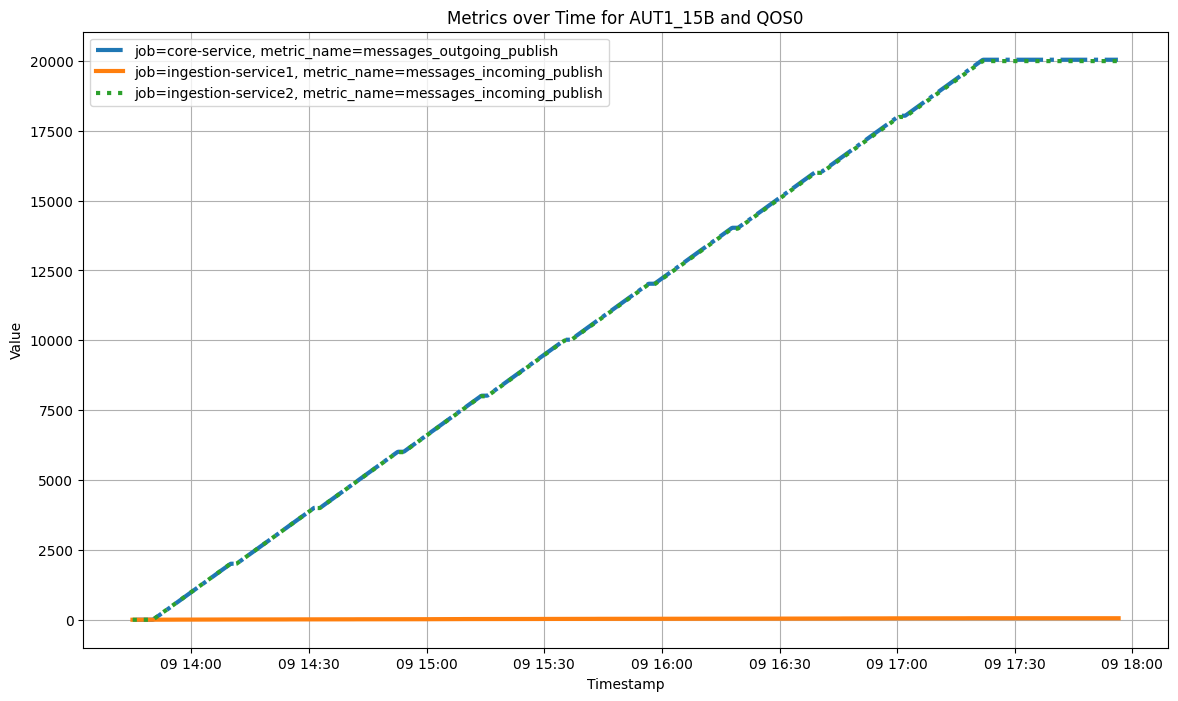

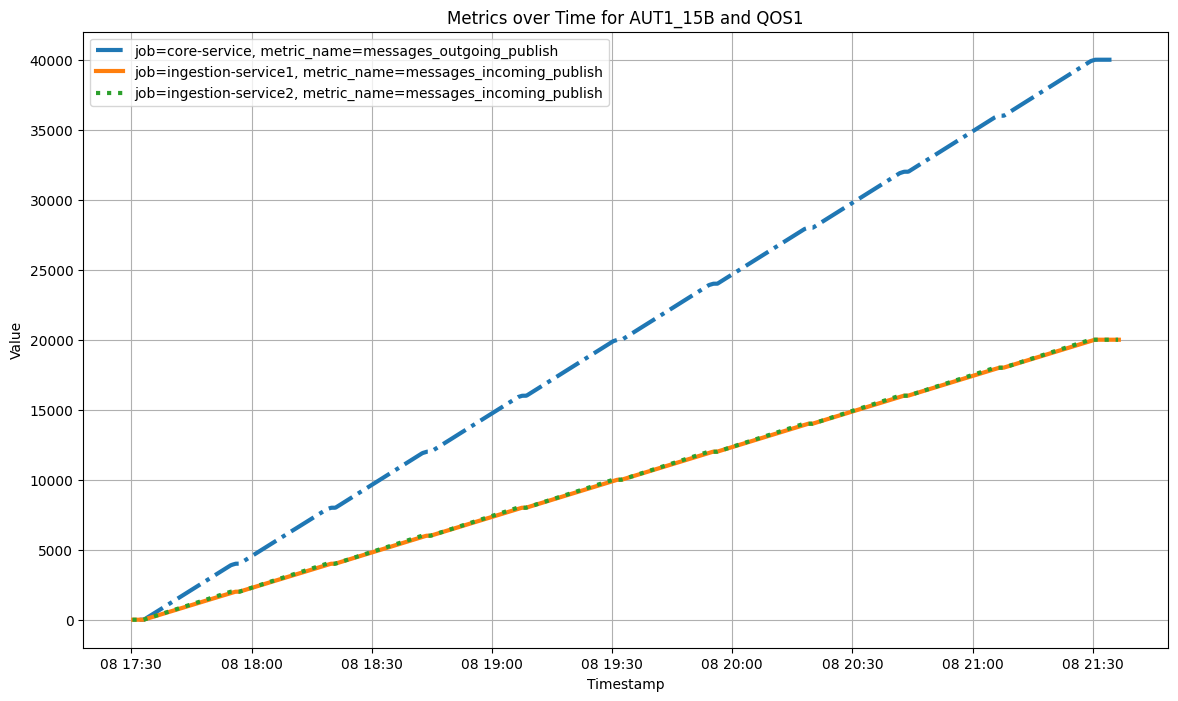

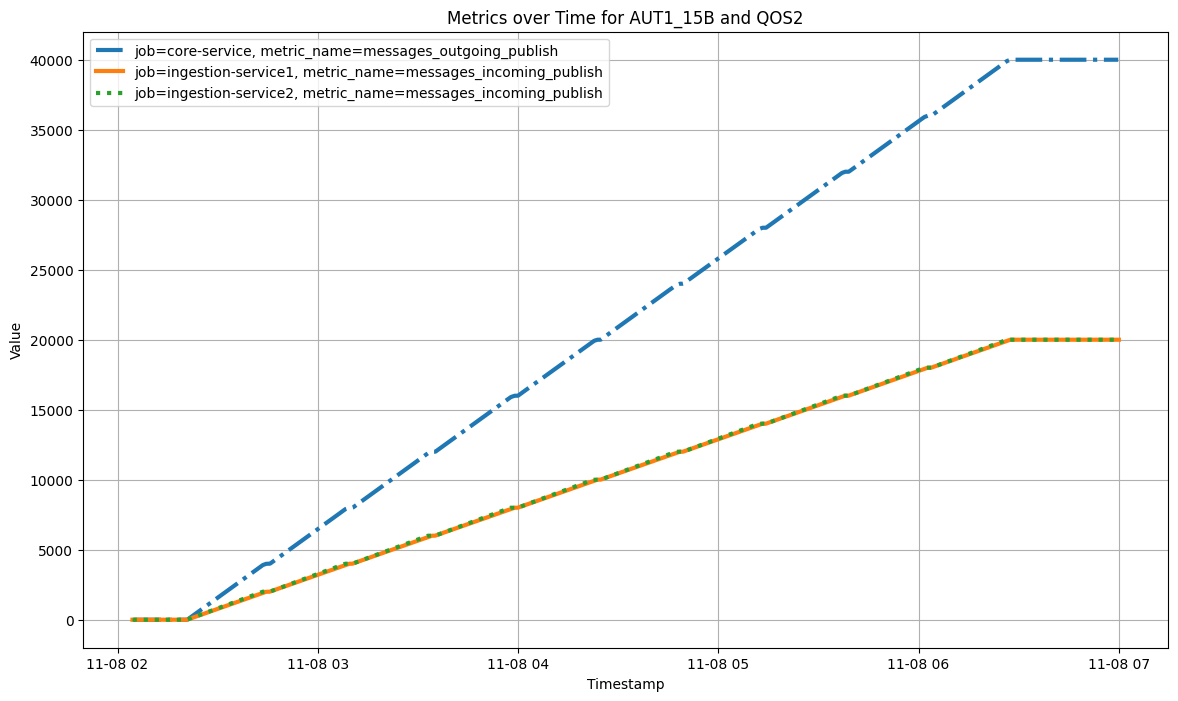

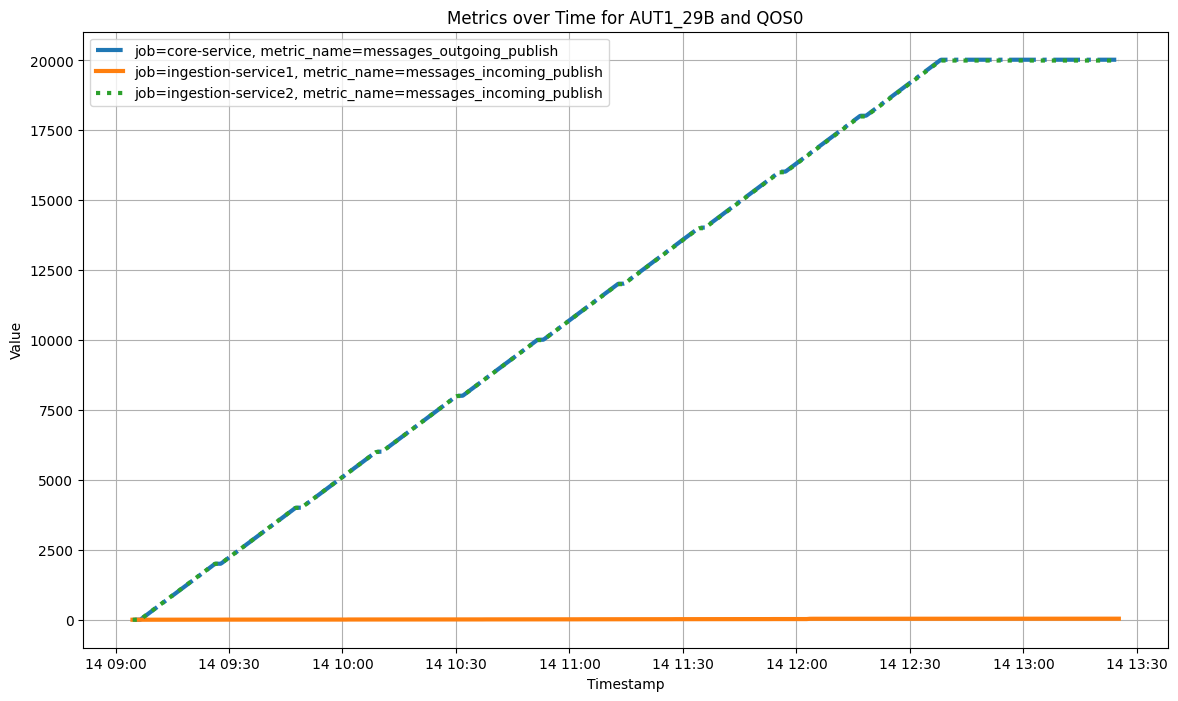

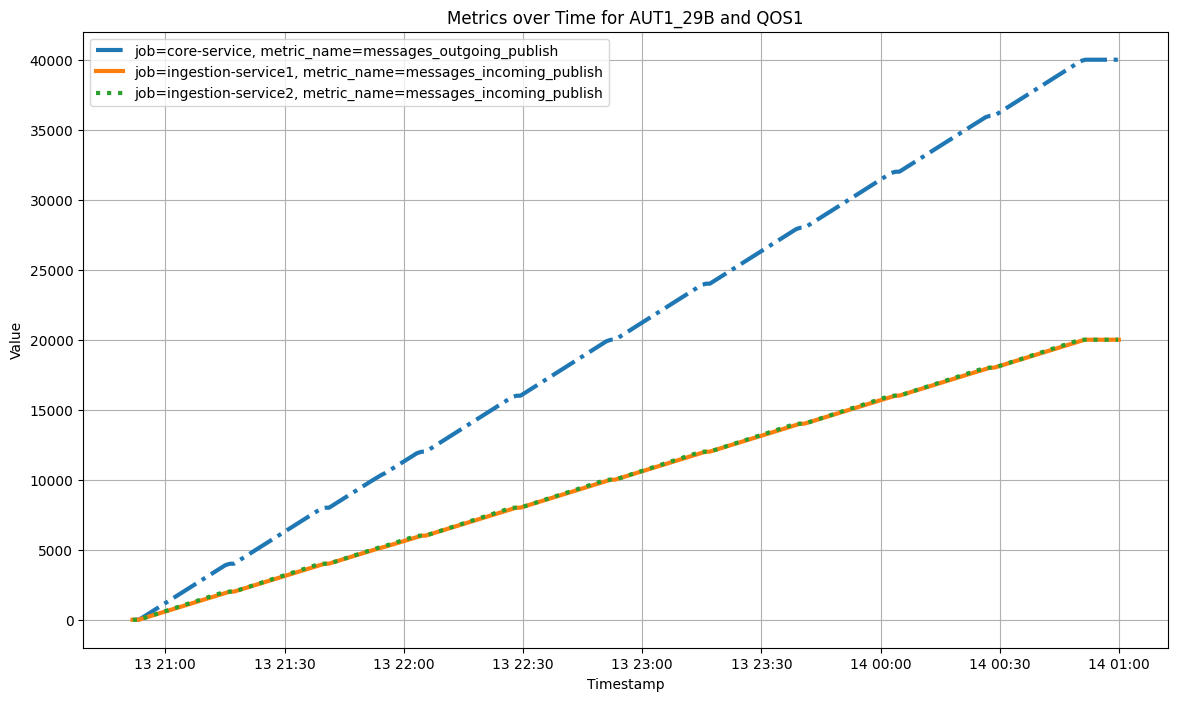

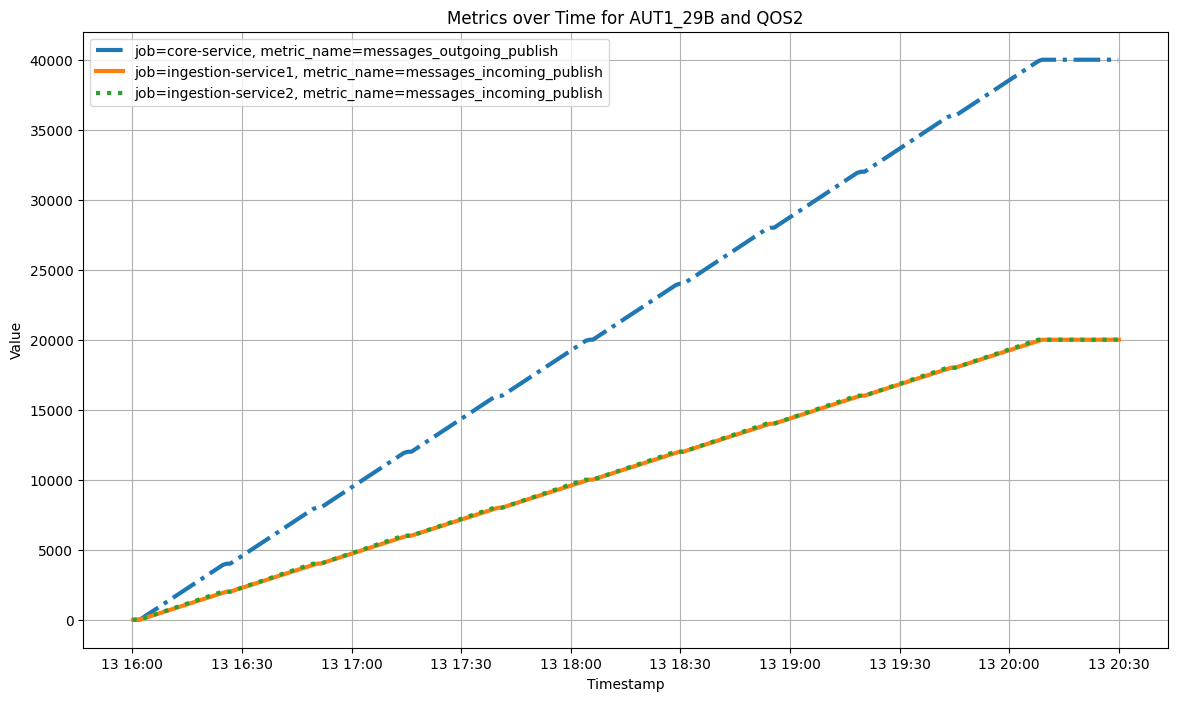

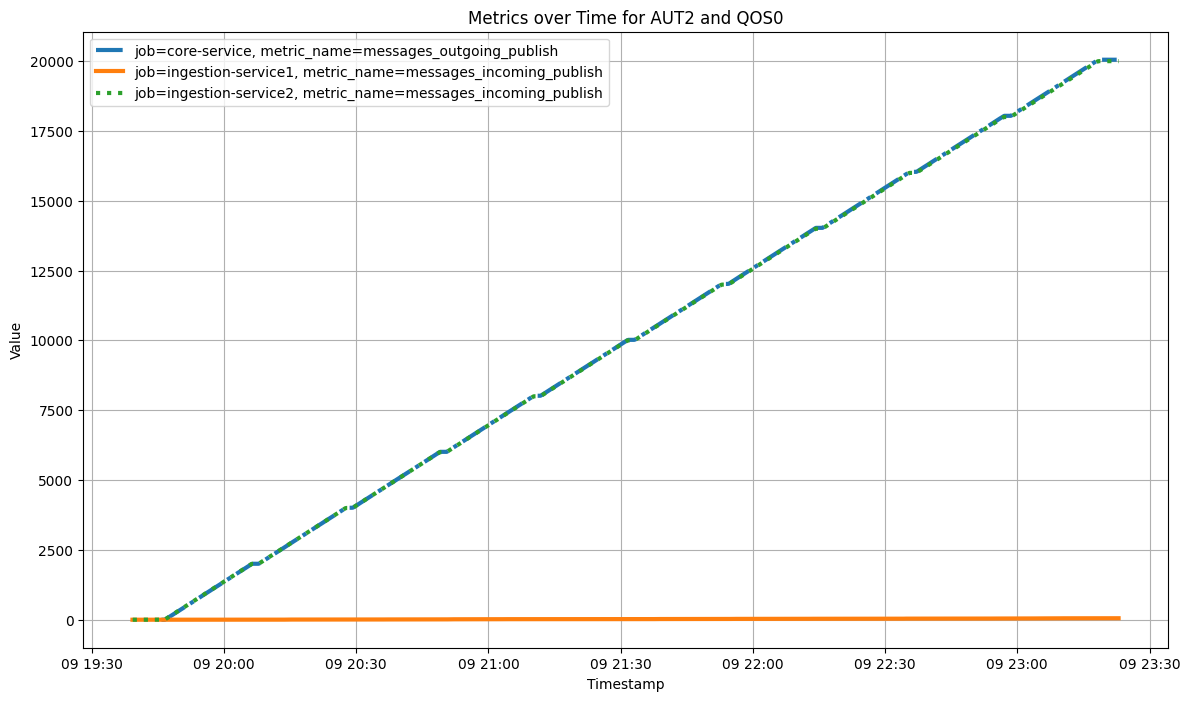

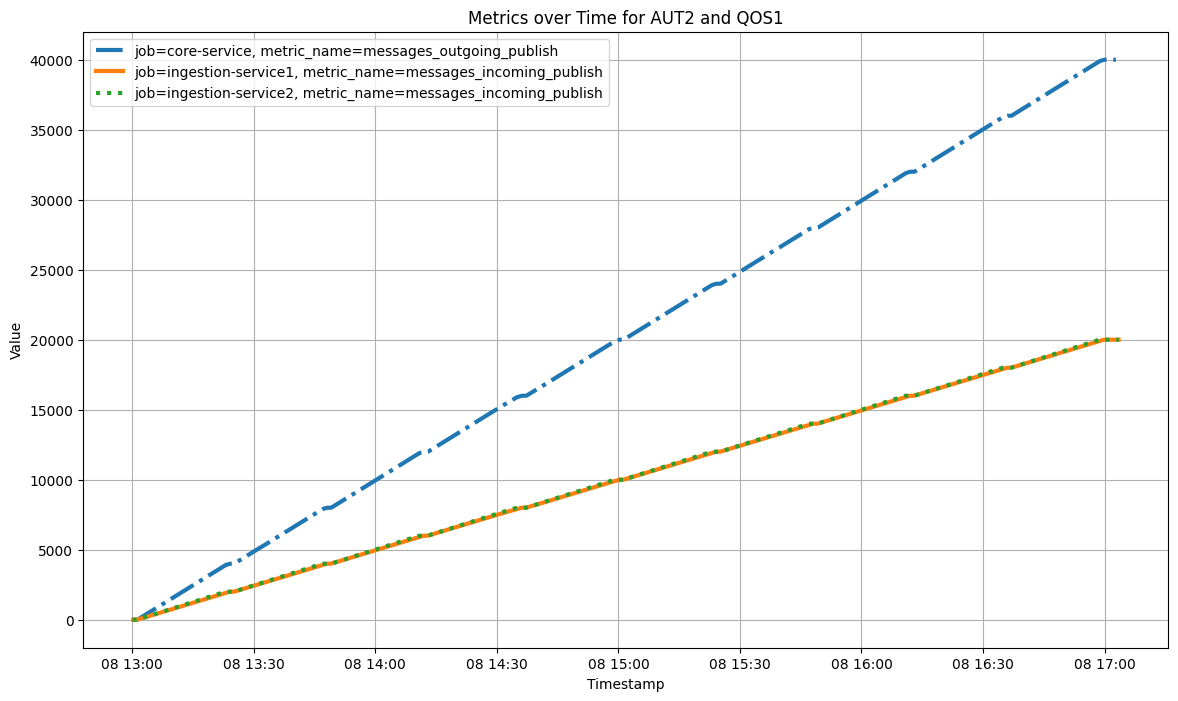

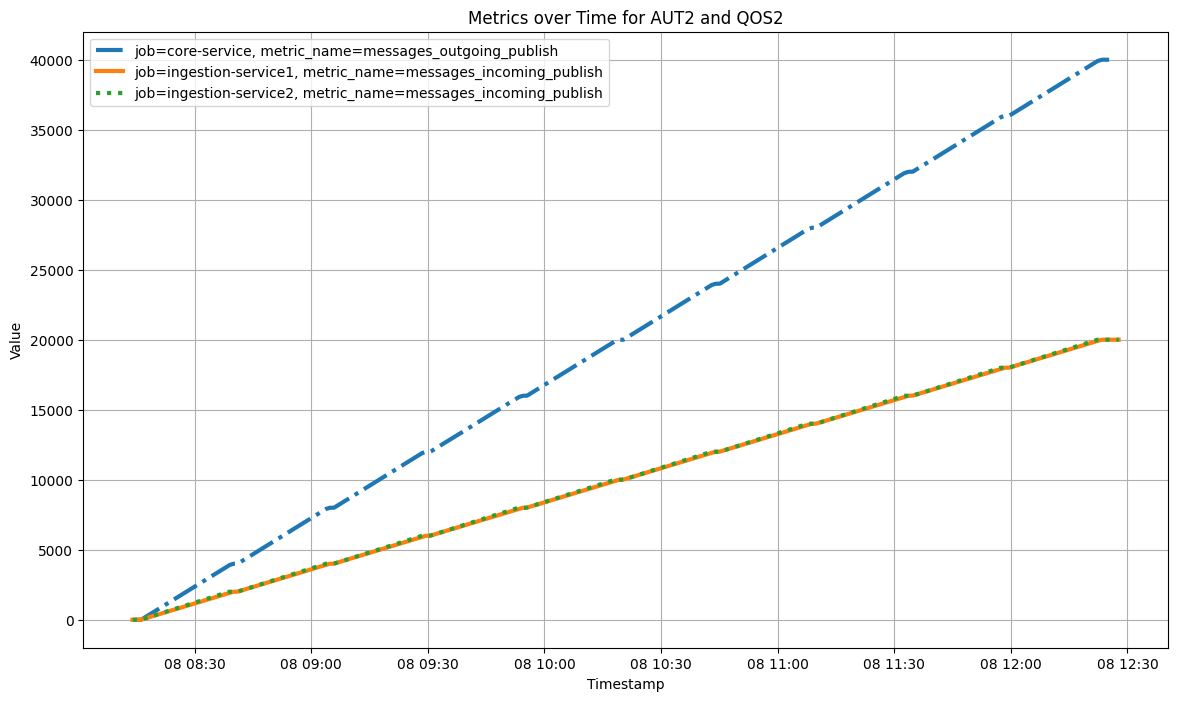

In [16]:
# Plot the time series grouped by aut, qos, job, and metric_name
plot_time_series_grouped(numpy_array)

### Arrange plots in grid

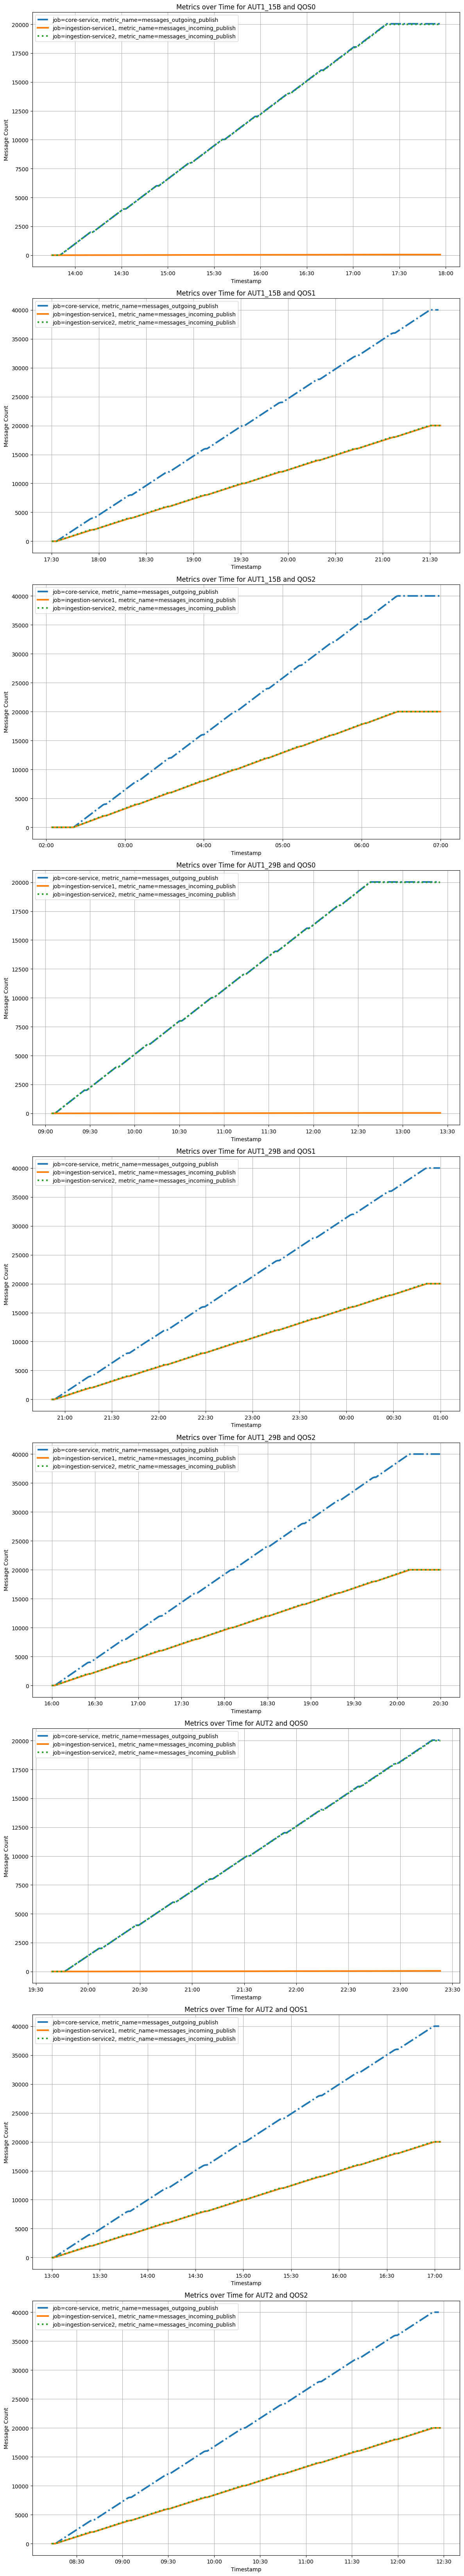

In [17]:
# Define your function for plotting
def plot_time_series_grouped_grid(data_array):
    # Extract unique values for aut and qos
    aut_values = np.unique(data_array['aut'])
    qos_values = np.unique(data_array['qos'])
    job_values = np.unique(data_array['job'])
    metric_name_values = np.unique(data_array['metric_name'])

    num_plots = len(aut_values) * len(qos_values)
    grid_size = (9, 1)  # Define the grid size

    # Create a grid of subplots
    fig, axs = plt.subplots(*grid_size, figsize=(12, 66))
    #fig.subplots_adjust(hspace=0.5, wspace=0.7)

    # Flatten the array of axes for easy iteration
    axs = axs.flatten()

    subplot_idx = 0

    # Iterate over each combination of aut and qos
    for aut in aut_values:
        for qos in qos_values:
            ax = axs[subplot_idx]
            ax.set_title(f'Metrics over Time for {aut.upper()} and {qos.upper()}')
            ax.set_xlabel('Timestamp')
            ax.set_ylabel('Message Count')
            ax.grid(True)

            # Iterate through job and metric_name combinations
            unique_combinations = np.array([(job, metric_name) for job in job_values for metric_name in metric_name_values])
            num_combinations = len(unique_combinations)

            for idx, (job, metric_name) in enumerate(unique_combinations):
                group_data = data_array[(data_array['aut'] == aut) & 
                                        (data_array['qos'] == qos) & 
                                        (data_array['job'] == job) & 
                                        (data_array['metric_name'] == metric_name)]
                
                if len(group_data) > 0 and metric_name == 'com_hivemq_messages_incoming_publish_count':
                    if job == 'core-service':
                        continue
                    if job == 'ingestion-service1':
                        ax.plot(group_data['timestamp'], group_data['value'], linestyle='-', 
                                 label=f'job={job}, metric_name={metric_name[11:-6]}', linewidth=3)
                    if job == 'ingestion-service2':
                        ax.plot(group_data['timestamp'], group_data['value'], linestyle=':', 
                                 label=f'job={job}, metric_name={metric_name[11:-6]}', linewidth=3)
                if len(group_data) > 0 and metric_name == 'com_hivemq_messages_outgoing_publish_count':
                    if job != 'core-service':
                        continue
                    ax.plot(group_data['timestamp'], group_data['value'], linestyle='-.', 
                             label=f'job={job}, metric_name={metric_name[11:-6]}', linewidth=3)

            # Format the date on the x-axis
            ax.xaxis.set_major_locator(mdates.AutoDateLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
            # ax.legend(loc='upper left', bbox_to_anchor=(1, 1))  # ,fontsize=8, prop={'size': 8}
            ax.legend(loc='best')

            # Update subplot index
            subplot_idx += 1

            # Break loop if we've plotted all required subplots
            if subplot_idx >= num_plots:
                break

    # remove unused axes
    for ax in axs.flat[num_plots:]:
        ax.remove()
    
    # Adjust layout to prevent labels from being cut off
    fig.tight_layout()
    #fig.autofmt_xdate()
    #fig.subplots_adjust(top=0.90)  # Add extra space at the top for the legend
    
    # Move the last legend below the plot
    #handles, labels = axs.flat[num_plots-1].get_legend_handles_labels()
    #plt.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 6),fontsize=10, prop={'size': 10})

    # Save plot
    plt.savefig('prometheus_host_machine.png', format='png')

    plt.show()

# Call function with data
plot_time_series_grouped_grid(numpy_array)

## AUT0 — Broker Comparison Metrics (CSV)

Loads per-broker Prometheus CSV files produced by `run_load_updated.py`  
(`results/<size>/<broker>_<size>_<qos>.csv`) and plots side-by-side comparisons  
for message throughput, byte throughput, CPU, and memory usage.

In [18]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = os.path.join(cwd, '..', 'results')

# ── Column mappings per broker ──────────────────────────────────────────────
BROKER_COL_MAP = {
    'hivemq': {
        'msgs_received': 'prom_com_hivemq_messages_incoming_publish_count',
        'msgs_sent':     'prom_com_hivemq_messages_outgoing_publish_count',
        'bytes_rx':      'prom_com_hivemq_networking_bytes_read_total',
        'bytes_tx':      'prom_com_hivemq_networking_bytes_written_total',
        'connections':   'prom_com_hivemq_subscriptions_overall_current',
    },
    'emqx': {
        'msgs_received': 'prom_emqx_messages_received',
        'msgs_sent':     'prom_emqx_messages_sent',
        'bytes_rx':      'prom_emqx_bytes_received',
        'bytes_tx':      'prom_emqx_bytes_sent',
        'connections':   'prom_emqx_connections_count',
    },
    'mosquitto': {
        'msgs_received': 'prom_broker_messages_received',
        'msgs_sent':     'prom_broker_messages_sent',
        'bytes_rx':      'prom_broker_bytes_received',
        'bytes_tx':      'prom_broker_bytes_sent',
        'connections':   'prom_broker_clients_connected',
    },
    'nanomq': {
        'msgs_received': 'prom_nanomq_messages_received',
        'msgs_sent':     'prom_nanomq_messages_sent',
        'bytes_rx':      None,  # not available
        'bytes_tx':      None,
        'connections':   'prom_nanomq_connections_count',
    },
    'rabbitmq': {
        'msgs_received': None,
        'msgs_sent':     None,
        'bytes_rx':      None,
        'bytes_tx':      None,
        'connections':   None,
    },
}

def _parse_bytes_str(s):
    """Convert '148kB' / '22.5MB' / '0B' strings to bytes (float). Returns NaN on failure."""
    if pd.isna(s):
        return np.nan
    if str(s).strip() == '0B':
        return 0.0
    s = str(s).strip()
    if s.endswith('GB'):
        return float(s[:-2]) * 1e9
    if s.endswith('MB'):
        return float(s[:-2]) * 1e6
    if s.endswith('kB'):
        return float(s[:-2]) * 1e3
    if s.endswith('B'):
        return float(s[:-1])
    return np.nan

frames = []
for csv_path in sorted(glob.glob(os.path.join(RESULTS_DIR, '**', '*.csv'), recursive=True)):
    df_raw = pd.read_csv(csv_path)
    broker = df_raw['broker'].iloc[0] if 'broker' in df_raw.columns else 'unknown'
    col_map = BROKER_COL_MAP.get(broker, {})

    def _col(key):
        src = col_map.get(key)
        if src and src in df_raw.columns:
            return df_raw[src]
        return pd.Series(np.nan, index=df_raw.index)

    df = pd.DataFrame({
        'broker':        df_raw['broker'],
        'payload_size':  df_raw.get('payload_size', '?'),
        'qos':           df_raw.get('qos', -1),
        'elapsed_s':     df_raw.get('elapsed_s', np.nan),
        'msgs_received': _col('msgs_received'),
        'msgs_sent':     _col('msgs_sent'),
        'bytes_rx':      _col('bytes_rx'),
        'bytes_tx':      _col('bytes_tx'),
        'connections':   _col('connections'),
        'cpu_pct':       pd.to_numeric(df_raw.get('broker_cpu_pct', np.nan), errors='coerce'),
        'mem_pct':       pd.to_numeric(df_raw.get('broker_mem_pct', np.nan), errors='coerce'),
        'net_rx_bytes':  df_raw.get('broker_net_rx', pd.Series(dtype=str)).apply(_parse_bytes_str),
        'net_tx_bytes':  df_raw.get('broker_net_tx', pd.Series(dtype=str)).apply(_parse_bytes_str),
    })
    frames.append(df)
    print(f'  Loaded {len(df):>3} rows from {os.path.basename(csv_path)}')

if frames:
    aut0_df = pd.concat(frames, ignore_index=True)
    # Use last row per (broker, qos) — cumulative metric snapshot at end of run
    summary = aut0_df.groupby(['broker', 'payload_size', 'qos']).last().reset_index()
    print(f'\nSummary ({len(summary)} experiments):')
    print(summary[['broker','payload_size','qos','msgs_received','msgs_sent','cpu_pct','mem_pct']].to_string(index=False))
else:
    print('[warn] No CSV files found under', RESULTS_DIR)


  Loaded  10 rows from emqx_125kb_qos0.csv
  Loaded  10 rows from hivemq_125kb_qos0.csv
  Loaded  10 rows from mosquitto_125kb_qos0.csv
  Loaded  10 rows from nanomq_125kb_qos0.csv
  Loaded  10 rows from rabbitmq_125kb_qos0.csv
  Loaded   1 rows from emqx_125kb_qos0.csv
  Loaded   1 rows from hivemq_125kb_qos0.csv
  Loaded   1 rows from mosquitto_125kb_qos0.csv
  Loaded   1 rows from nanomq_125kb_qos0.csv
  Loaded   1 rows from rabbitmq_125kb_qos0.csv
  Loaded  10 rows from emqx_16mb_qos0.csv
  Loaded  10 rows from hivemq_16mb_qos0.csv
  Loaded  10 rows from mosquitto_16mb_qos0.csv
  Loaded  10 rows from nanomq_16mb_qos0.csv
  Loaded  10 rows from rabbitmq_16mb_qos0.csv
  Loaded   1 rows from emqx_16mb_qos0.csv
  Loaded   1 rows from hivemq_16mb_qos0.csv
  Loaded   1 rows from mosquitto_16mb_qos0.csv
  Loaded   1 rows from nanomq_16mb_qos0.csv
  Loaded   1 rows from rabbitmq_16mb_qos0.csv
  Loaded  10 rows from emqx_1kb_qos0.csv
  Loaded  10 rows from hivemq_1kb_qos0.csv
  Loaded  10 r

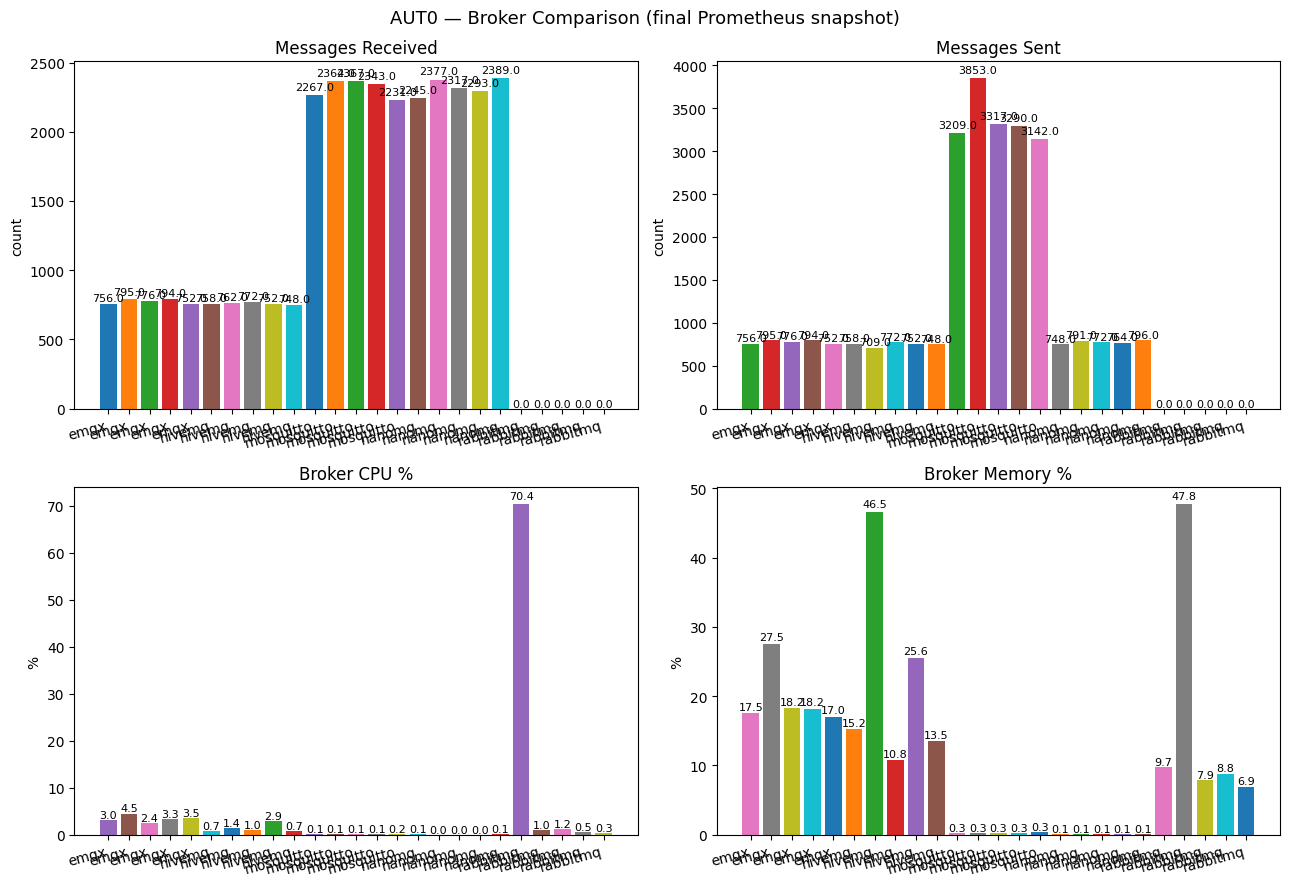

In [19]:
if 'summary' not in dir() or summary.empty:
    print('[skip] No data loaded')
else:
    brokers = summary['broker'].tolist()
    x = range(len(brokers))
    colors = plt.cm.tab10.colors

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle('AUT0 — Broker Comparison (final Prometheus snapshot)', fontsize=13)

    def _bar(ax, values, title, ylabel, color_offset=0):
        bars = ax.bar(x, values, color=[colors[(i + color_offset) % 10] for i in range(len(brokers))])
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xticks(list(x))
        ax.set_xticklabels(brokers, rotation=15, ha='right')
        for bar, val in zip(bars, values):
            if not pd.isna(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                        f'{val:.1f}', ha='center', va='bottom', fontsize=8)

    _bar(axes[0,0], summary['msgs_received'].fillna(0), 'Messages Received', 'count')
    _bar(axes[0,1], summary['msgs_sent'].fillna(0),     'Messages Sent',     'count', 2)
    _bar(axes[1,0], summary['cpu_pct'].fillna(0),       'Broker CPU %',      '%',     4)
    _bar(axes[1,1], summary['mem_pct'].fillna(0),       'Broker Memory %',   '%',     6)

    plt.tight_layout()
    plt.show()


## AUT0 — Prometheus Time-Series (Range Query)

Loads the per-experiment Prometheus range JSON files written by `run_load_updated.py`
(`results/<broker>/<size>/qos<N>/<experiment_id>_prometheus.json`) and plots
broker-side incoming vs outgoing message counts over time.

This lets you visually confirm where message drop-off occurs (e.g. HiveMQ at 125 KB
shows messages received but not forwarded) and cross-validate the subscriber-log
loss rate with a broker-side `broker_loss_rate = 1 - outgoing/incoming` figure.